# Periodogram 

## This notebook aims to perform an analysis of the seasonal component of each time series for each patient.


For this purpose, we define our time series as follows 

$$

z_t = \sum_{t=1}^{T/2} A_j \sin(\omega_j t) + B_j \cos(\omega_j t)

$$



The upper limit of the summation is determined by the definition of the seasonal periods $s_j$. Specifically, we define:
$$
s_j = \frac{T}{j}, \quad \text{for } j = 1, 2, \dots, \left\lfloor \frac{T}{2} \right\rfloor,
$$
which implies that the set of possible seasonal periods is:
$$
s = \{2, 3, \dots, T\}.
$$

From this, we can derive bounds on the corresponding seasonal frequencies $f_j = 1/s_j$. Since $2 \leq s_j \leq T$, it follows that:
$$
\frac{1}{T} \leq f_j \leq \frac{1}{2}.
$$



In this way we can compute all coefficients $$ A_j $$ and $$ B_j $$ for all basic frequencies as the first equation establish. As we're interested at the waves with high amplitudes, we use a function of the frequency to discover those amplitudes, we compute it as follows:

$$
I(f_j) = \frac{T}{2} \, \hat{R}_j^2,
$$

Where:

$$
    \hat{R_j}^2 = \hat{A_j}^2 + \hat{B_j}^2
$$

And :

$$
\hat{A}_j = \frac{2}{T} \sum_{t=1}^{T} z_t \sin(\omega_j t), \qquad
\hat{B}_j = \frac{2}{T} \sum_{t=1}^{T} z_t \cos(\omega_j t),
$$

with $\omega_j = 2\pi f_j = \frac{2\pi j}{T}$ for $j = 1, \dots, \lfloor T/2 \rfloor$.

In [14]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 

In [15]:
def compute_coefficients(zt, frequencies):
    T = len(zt)
    t = np.arange(T)
    
    omega_t = 2 * np.pi * frequencies.reshape(-1, 1) * t
    
    a_j = (2/T) * np.sum(zt.values * np.sin(omega_t), axis=1)
    b_j = (2/T) * np.sum(zt.values * np.cos(omega_t), axis=1)
    
    return a_j, b_j

In [16]:
def periodogram(zt):
    T = len(zt)
    num_freq = T//2 + 1
    frequencies = np.linspace(1/T, 1/2, num=num_freq, dtype=np.float32)
    
    a_j, b_j = compute_coefficients(zt, frequencies)
    periodogram = (T/2) * (np.square(a_j) + np.square(b_j))
    return dict(zip(frequencies, periodogram))

In [17]:
def plot_periodogram(zt):
    T = len(zt)
    I_f = periodogram(zt)
    
    plt.figure(figsize=(12, 6))
    plt.plot(I_f.keys(), I_f.values())
    plt.xlabel('Frequency')
    plt.ylabel('Amplitude')
    plt.title('Periodogram')
    plt.grid(True)
    plt.show()

Now, let's read all patients and plot the periodogram 

In [18]:
import os 

data_dir = '../Data/Preprocessed'
base_paths = os.listdir(data_dir)
full_paths = [os.path.join(data_dir, p) for p in base_paths]

In [19]:
def cast_to_time(df):
    df['time'] = pd.to_datetime(df['time'])
    return df

In [20]:
patients = {base_paths[i].split('.')[0] : cast_to_time(pd.read_csv(fp, sep=';')) for i, fp in enumerate(full_paths)}

In [21]:
def create_two_plots(two_series_dictionary):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    i = 0
    for key, value in two_series_dictionary.items():
        ax_i = axes[i]
        periodogram_i = periodogram(value['glucose'])
        ax_i.plot(periodogram_i.keys(), np.log(list(periodogram_i.values())))
        ax_i.set(title = key)
        ax_i.grid()
        i += 1
    plt.tight_layout()
    plt.show()


In [22]:
import gc

In [23]:
def plot_periodograms(keys, patients):
    num_patients = len(keys)
    print(num_patients)
    i = 0
    j = 1
    while j < num_patients:
        key_1 = keys[i]
        key_2 = keys[j]
        temp_dict = {key_1 : patients[key_1], key_2 : patients[key_2]}
        create_two_plots(temp_dict)
        plt.close('all')  
        del temp_dict     
        gc.collect()     
        i += 2
        j = i + 1

In [24]:
keys = list(patients.keys())[:-3]

12


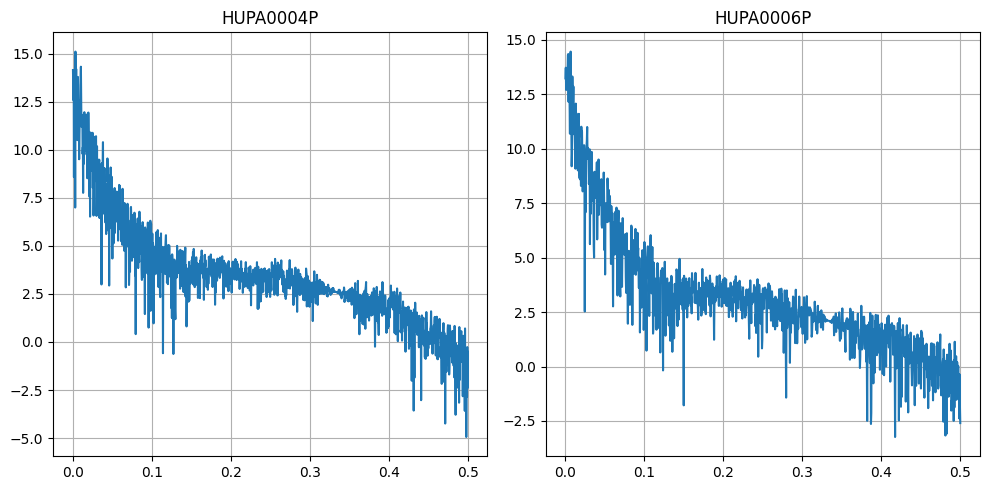

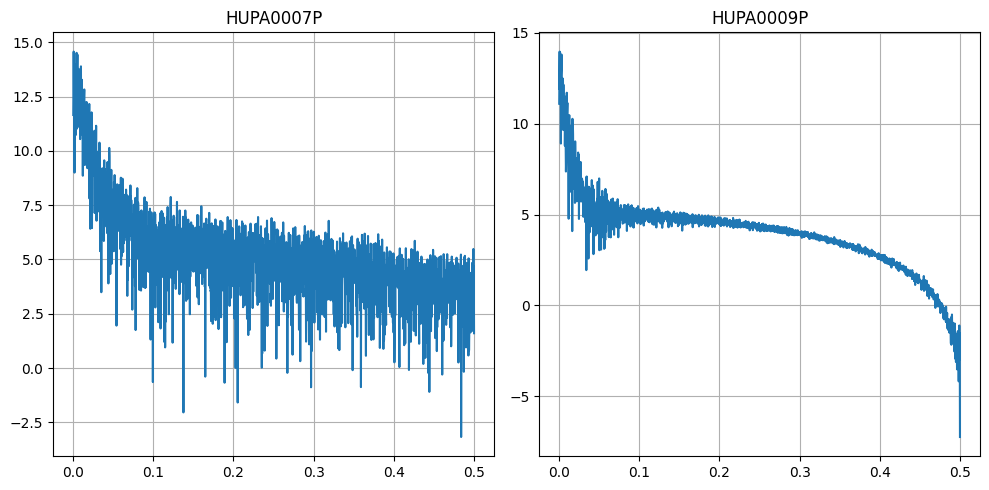

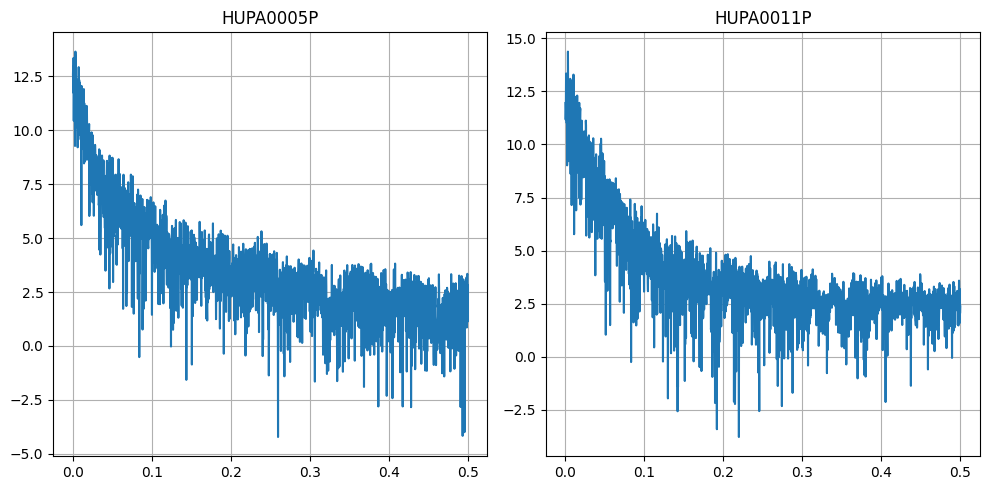

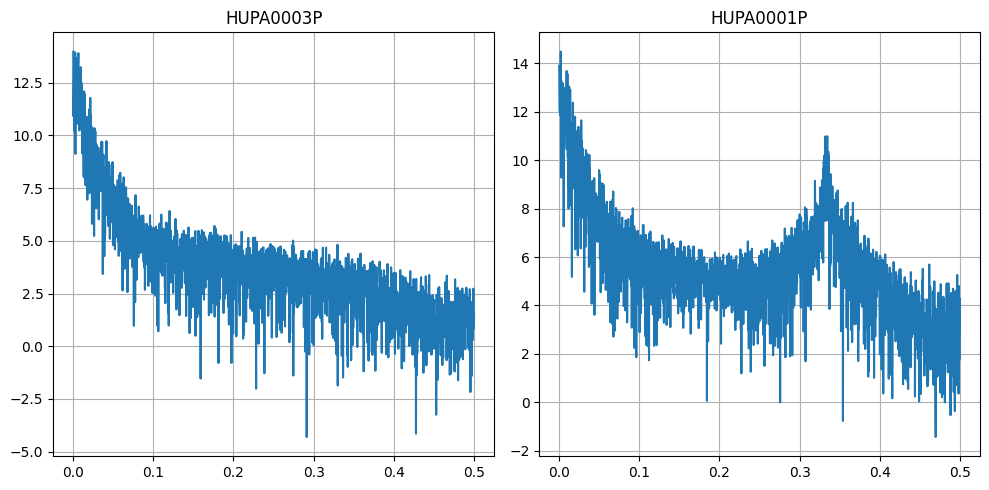

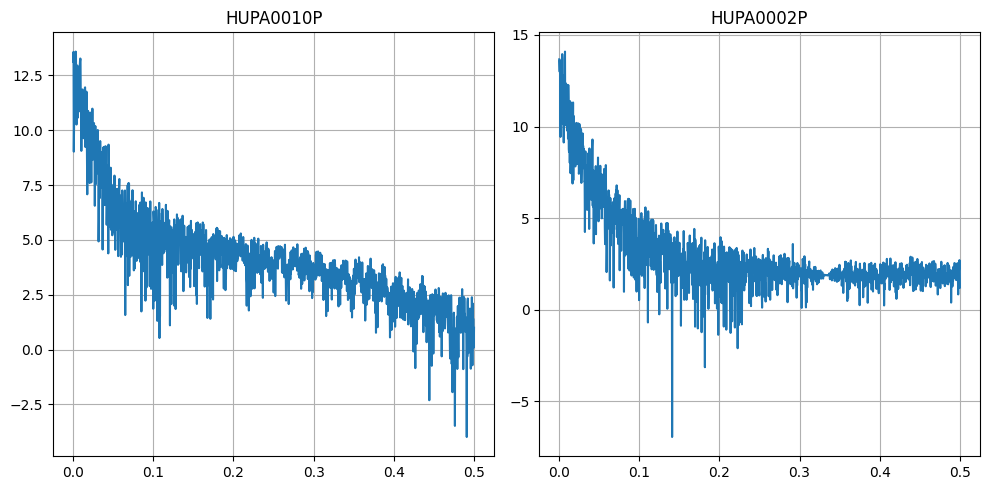

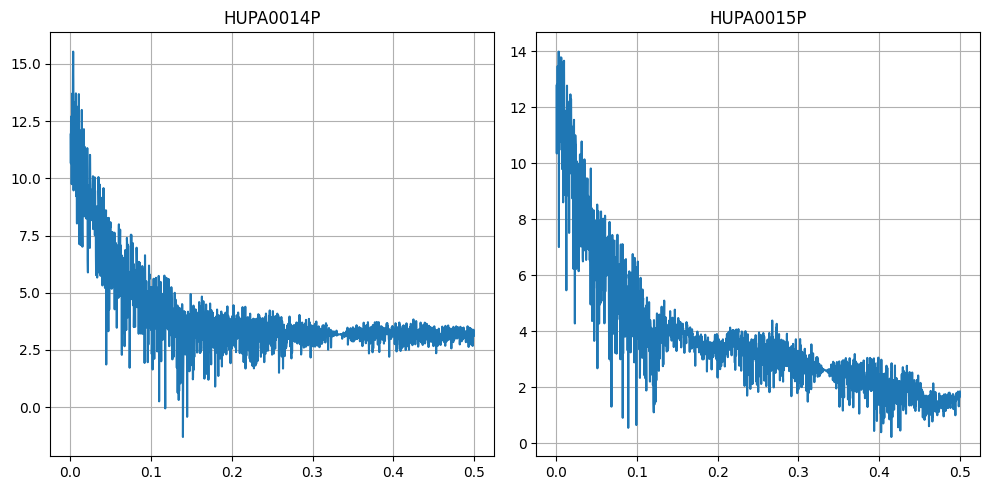

In [25]:
plot_periodograms(keys[:12], patients)

10


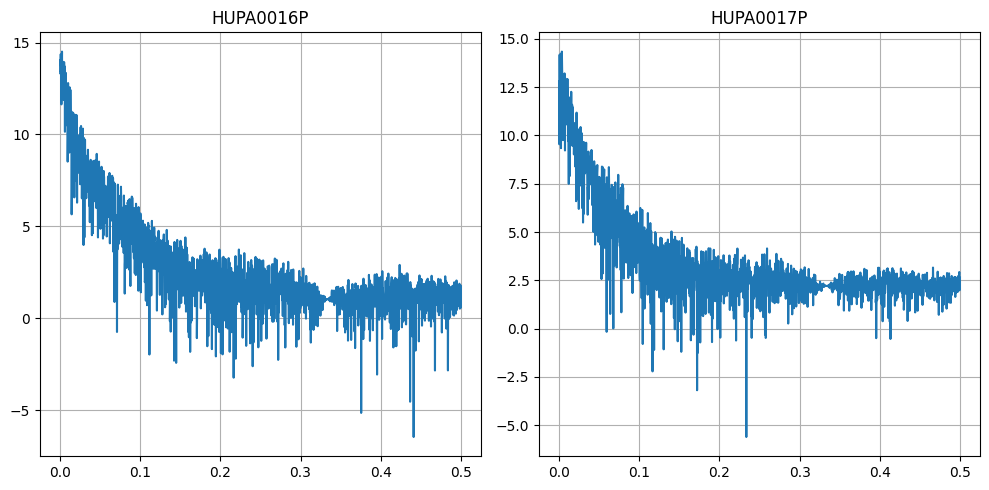

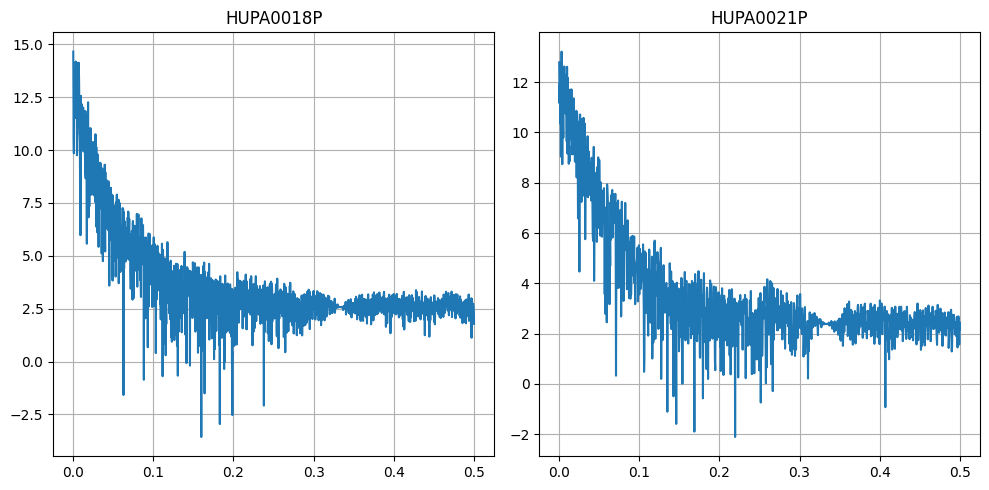

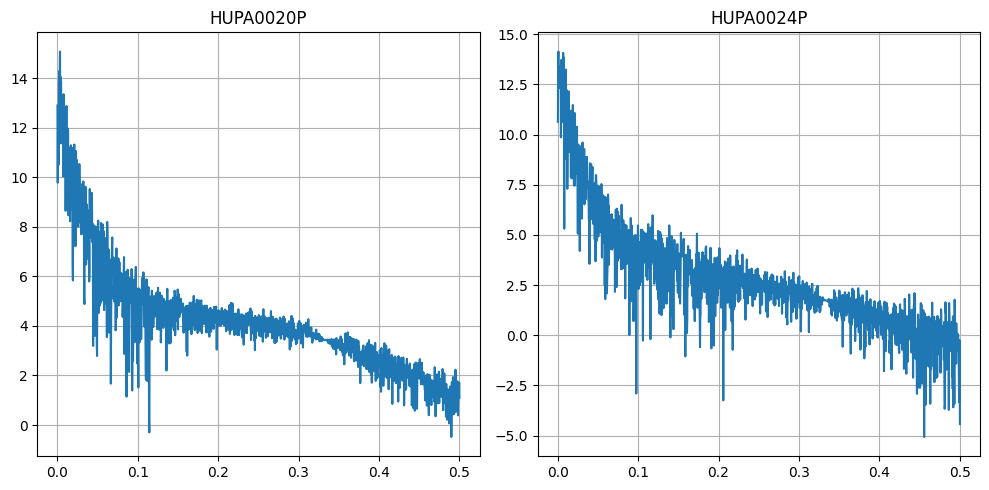

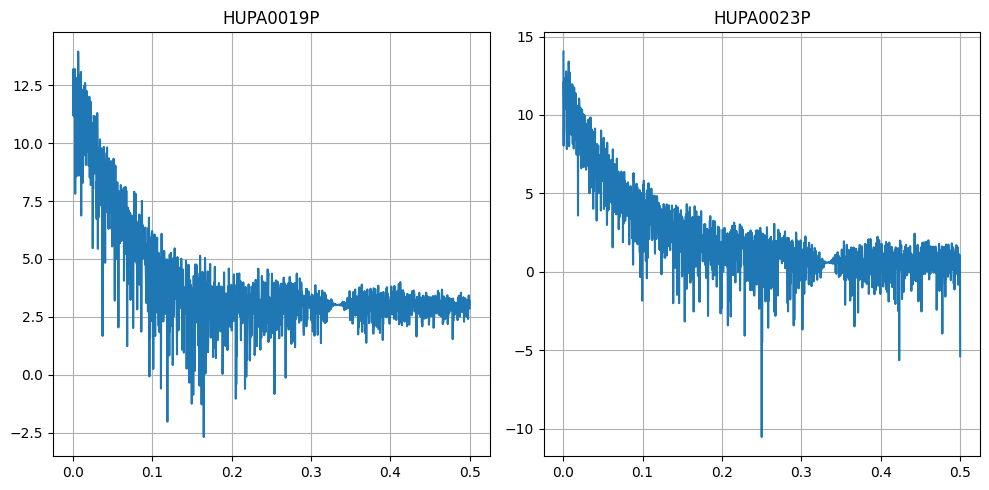

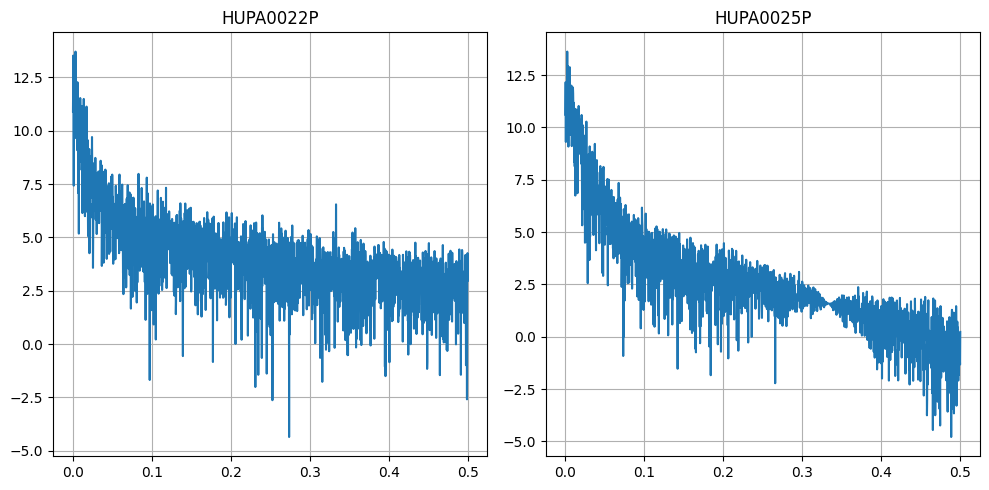

In [26]:
plot_periodograms(keys[12:], patients)

In [45]:
def get_season(x):
    return [1/x[0], x[1]]

In [48]:
top_frequencies_all_patients = {key:list(map(get_season, sorted(periodogram(patients[key]['glucose']).items(), key=lambda x : x[1], reverse=True)))[:5] for key in keys}

In [53]:
top_frequencies_all_patients

{'HUPA0004P': [[np.float32(289.61993), np.float64(3615200.567104218)],
  [np.float32(96.543655), np.float64(1647861.668957932)],
  [np.float32(227.5613), np.float64(1465177.9547444757)],
  [np.float32(3184.0), np.float64(1385752.8490248853)],
  [np.float32(796.3752), np.float64(1250617.0674495937)]],
 'HUPA0006P': [[np.float32(143.2423), np.float64(1906352.1435244062)],
  [np.float32(254.64214), np.float64(1704235.558515751)],
  [np.float32(286.46893), np.float64(1617979.539702939)],
  [np.float32(208.34723), np.float64(1153135.1201540334)],
  [np.float32(152.79121), np.float64(1147627.0938561999)]],
 'HUPA0007P': [[np.float32(1285.889), np.float64(2135550.8347057467)],
  [np.float32(226.93773), np.float64(2019233.6277899002)],
  [np.float32(183.71204), np.float64(1859631.7612706183)],
  [np.float32(385.79004), np.float64(1164217.5026705165)],
  [np.float32(101.525635), np.float64(1083003.403338403)]],
 'HUPA0009P': [[np.float32(1271.1112), np.float64(1171284.6296645356)],
  [np.float3